## 01 - Data Exploration and Preprocessing

This notebook performs an initial exploration of the job-posting dataset
to understand its structure, quality, characteristics, and suitability
for job-market skill demand analysis and career recommendation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
df = pd.read_csv("data/job_postings.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 15000
Number of columns: 16


In [5]:
df.columns

Index(['job_id', 'title', 'company', 'location', 'remote_type', 'industry',
       'company_size', 'experience_level', 'salary_min', 'salary_max',
       'required_skills', 'education_required', 'description', 'posted_date',
       'applications', 'days_to_fill'],
      dtype='object')

In [6]:
df.head()

,job_id,title,company,location,remote_type,industry,company_size,experience_level,salary_min,salary_max,required_skills,education_required,description,posted_date,applications,days_to_fill
0,JOB13473,Data Scientist,PolicyData Corp,"Pittsburgh, PA",onsite,government,startup,senior,138000,164000,Jupyter|Deep Learning|Python|Statistics|NLP|SQL|A/B Testing,bachelor,Join PolicyData Corp as a senior Data Scientist and help us build product analytics infrastructu...,2023-01-01,26,61
1,JOB10866,Data Engineer,LearnEdge Systems,"Omaha, NE",remote,education,medium,mid,85000,103000,Python|PostgreSQL|BigQuery|Spark,bachelor,"LearnEdge Systems is looking for a passionate Data Engineer with expertise in Python, PostgreSQL...",2023-01-01,75,55
2,JOB12905,Product Manager,Keystone Public Analytics,"Albuquerque, NM",hybrid,government,startup,entry,63000,77000,User Research|JIRA,bachelor,Join Keystone Public Analytics as a entry Product Manager and help us build enterprise data plat...,2023-01-01,22,34
3,JOB01986,Research Scientist,Quantum Leap Digital,"Albuquerque, NM",onsite,tech,startup,entry,61000,71000,PyTorch|Statistics,bachelor,Quantum Leap Digital is looking for a passionate Research Scientist with expertise in PyTorch an...,2023-01-01,18,37
4,JOB07952,Backend Engineer,Fabricate AI,"Albuquerque, NM",onsite,manufacturing,large,director,208000,245000,Python|PostgreSQL|Redis|Java|Docker|REST APIs|Go|gRPC|SQL,master,"As a director Backend Engineer at Fabricate AI, you will leverage Python, PostgreSQL, and Redis ...",2023-01-01,131,114


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   job_id              15000 non-null  object
 1   title               15000 non-null  object
 2   company             15000 non-null  object
 3   location            15000 non-null  object
 4   remote_type         15000 non-null  object
 5   industry            15000 non-null  object
 6   company_size        15000 non-null  object
 7   experience_level    15000 non-null  object
 8   salary_min          15000 non-null  int64 
 9   salary_max          15000 non-null  int64 
 10  required_skills     15000 non-null  object
 11  education_required  15000 non-null  object
 12  description         15000 non-null  object
 13  posted_date         15000 non-null  object
 14  applications        15000 non-null  int64 
 15  days_to_fill        15000 non-null  int64 
dtypes: int64(4), object(12

In [10]:
missing_values = df.isnull().sum()

print(missing_values)

job_id                0
title                 0
company               0
location              0
remote_type           0
industry              0
company_size          0
experience_level      0
salary_min            0
salary_max            0
required_skills       0
education_required    0
description           0
posted_date           0
applications          0
days_to_fill          0
dtype: int64


In [12]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [13]:
print("Duplicate Job IDs:", df['job_id'].duplicated().sum())

Duplicate Job IDs: 0


In [14]:
df.describe()

,salary_min,salary_max,applications,days_to_fill
count,15000.000000,15000.000000,15000.000000,15000.000000
mean,146675.333333,183369.933333,101.238267,56.067067
std,62131.326063,78274.867484,64.810472,31.156191
min,42000.000000,49000.000000,10.000000,15.000000
25%,99000.000000,124000.000000,45.000000,34.000000
50%,136000.000000,170000.000000,83.000000,48.000000
75%,182000.000000,228000.000000,143.000000,72.000000
max,466000.000000,576000.000000,276.000000,180.000000


In [15]:
df[['salary_min', 'salary_max', 'applications', 'days_to_fill']].describe()

,salary_min,salary_max,applications,days_to_fill
count,15000.000000,15000.000000,15000.000000,15000.000000
mean,146675.333333,183369.933333,101.238267,56.067067
std,62131.326063,78274.867484,64.810472,31.156191
min,42000.000000,49000.000000,10.000000,15.000000
25%,99000.000000,124000.000000,45.000000,34.000000
50%,136000.000000,170000.000000,83.000000,48.000000
75%,182000.000000,228000.000000,143.000000,72.000000
max,466000.000000,576000.000000,276.000000,180.000000


In [16]:
print("Unique job titles:", df['title'].nunique())

df['title'].value_counts().head(20)

Unique job titles: 10


title
Software Engineer     1552
UX Designer           1550
Product Manager       1520
Data Analyst          1520
ML Engineer           1514
Data Engineer         1496
Data Scientist        1484
Backend Engineer      1463
DevOps Engineer       1452
Research Scientist    1449
Name: count, dtype: int64

In [17]:
print("Unique industries:", df['industry'].nunique())

df['industry'].value_counts()

Unique industries: 8


industry
finance          1924
education        1913
government       1894
media            1873
manufacturing    1867
retail           1857
tech             1842
healthcare       1830
Name: count, dtype: int64

In [18]:
df['experience_level'].value_counts()

experience_level
mid         4378
senior      4258
entry       3037
lead        2096
director    1231
Name: count, dtype: int64

In [19]:
df['education_required'].value_counts()

education_required
bachelor    7591
master      4747
phd         1952
none         710
Name: count, dtype: int64

In [20]:
df['remote_type'].value_counts()

remote_type
hybrid    6002
onsite    4506
remote    4492
Name: count, dtype: int64

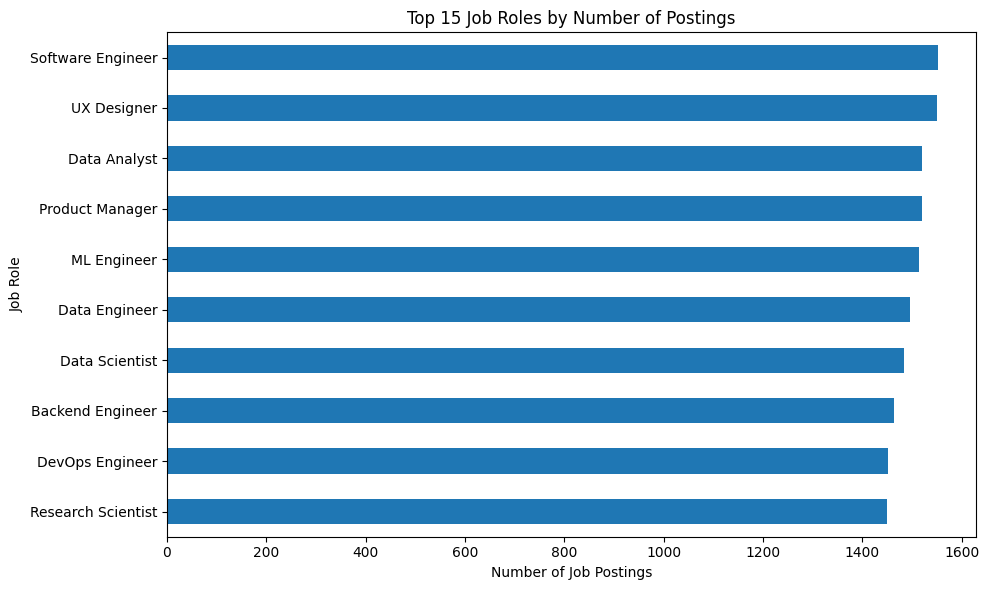

In [21]:
top_jobs = df['title'].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_jobs.sort_values().plot(kind='barh')

plt.title('Top 15 Job Roles by Number of Postings')
plt.xlabel('Number of Job Postings')
plt.ylabel('Job Role')
plt.tight_layout()
plt.show()

In [22]:
skills_series = df['required_skills'].dropna().str.split('|').explode()

skills_series = skills_series.str.strip()

print("Total skill records:", len(skills_series))
print("Unique skills:", skills_series.nunique())

Total skill records: 87368
Unique skills: 69


In [23]:
top_skills = skills_series.value_counts().head(20)

top_skills

required_skills
Python              5873
SQL                 4363
Docker              2675
Kubernetes          2673
AWS                 2672
Statistics          2454
A/B Testing         2432
TensorFlow          2330
PyTorch             2304
Spark               2064
PostgreSQL          1911
User Research       1893
Figma               1869
Machine Learning    1574
Deep Learning       1550
dbt                 1547
Tableau             1482
Airflow             1403
CI/CD               1394
Kafka               1388
Name: count, dtype: int64